3.2 Project: Machine Learning Models Implementation - JESSOS3674 - 29 MAY 2026

In [1]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

# Dynamic date: YYYY-MM-DD
date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 1 - Imports and Load Raw Data"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- IMPORTS ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set(style="whitegrid")

# --- FILE PATH ---
base_path = r"C:\Users\cis101\Downloads\archive\\"

# --- LOAD RAW INSTACART DATA ---
orders = pd.read_csv(base_path + "orders.csv")
order_products_prior = pd.read_csv(base_path + "order_products__prior.csv")
products = pd.read_csv(base_path + "products.csv")
aisles = pd.read_csv(base_path + "aisles.csv")
departments = pd.read_csv(base_path + "departments.csv")

print("Datasets Loaded Successfully.")
print("\nShapes:")
print(f"orders: {orders.shape}")
print(f"order_products_prior: {order_products_prior.shape}")
print(f"products: {products.shape}")
print(f"aisles: {aisles.shape}")
print(f"departments: {departments.shape}")

Step 1 - Imports and Load Raw Data

Student ID: JESSOS3674

Date: 2026-06-11

Datasets Loaded Successfully.

Shapes:
orders: (3421083, 7)
order_products_prior: (32434489, 4)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


In [2]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 2 - Sample Users and Reduce Dataset Size"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- SAMPLE USERS ---
# Randomly select 10,000 unique users to create a manageable subset
sample_users = orders["user_id"].drop_duplicates().sample(n=10000, random_state=42)

# Filter orders and order_products_prior for these users
orders_sample = orders[orders["user_id"].isin(sample_users)]
order_products_sample = order_products_prior[order_products_prior["order_id"].isin(orders_sample["order_id"])]

print("Sampling Complete.")
print("\nShapes After Sampling:")
print(f"orders_sample: {orders_sample.shape}")
print(f"order_products_sample: {order_products_sample.shape}")

Step 2 - Sample Users and Reduce Dataset Size

Student ID: JESSOS3674

Date: 2026-06-11

Sampling Complete.

Shapes After Sampling:
orders_sample: (166896, 7)
order_products_sample: (1578962, 4)


In [3]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 3 - Merge Data Tables"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- MERGE DATA TABLES ---
# Merge product metadata (products → aisles → departments)
product_meta = (
    products
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

# Merge order-product data with product metadata
merged_df = order_products_sample.merge(product_meta, on="product_id", how="left")

# Merge with order information
merged_df = merged_df.merge(orders_sample, on="order_id", how="left")

print("Merging Complete.")
print("\nMerged Dataset Shape:", merged_df.shape)
print("Columns:\n", merged_df.columns.tolist())

Step 3 - Merge Data Tables

Student ID: JESSOS3674

Date: 2026-06-11

Merging Complete.

Merged Dataset Shape: (1578962, 15)
Columns:
 ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


In [4]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 4 - Create Classification Dataset and Clean Data"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- CREATE CLASSIFICATION DATASET ---
classification_df = merged_df[[
    "user_id", "order_id", "product_id", "add_to_cart_order",
    "order_hour_of_day", "order_dow", "days_since_prior_order",
    "aisle", "department", "reordered"
]].copy()

print("Initial Missing Values:\n")
print(classification_df.isnull().sum())

# --- HANDLE MISSING VALUES ---
median_days = classification_df["days_since_prior_order"].median()
classification_df["days_since_prior_order"].fillna(median_days, inplace=True)

print("\nMissing Values After Imputation:\n")
print(classification_df.isnull().sum())

# --- ENCODE CATEGORICAL VARIABLES ---
label_cols = ["aisle", "department"]
le = LabelEncoder()

for col in label_cols:
    classification_df[col] = le.fit_transform(classification_df[col])

print("\nCategorical Columns Encoded Successfully.")

# --- SCALE NUMERIC FEATURES ---
numeric_cols = ["order_hour_of_day", "order_dow", "days_since_prior_order", "add_to_cart_order"]
scaler = StandardScaler()
classification_df[numeric_cols] = scaler.fit_transform(classification_df[numeric_cols])

print("\nNumeric Columns Scaled Successfully.")

# --- FINAL CHECK ---
print("\nFinal Dataset Shape:", classification_df.shape)
print("\nData Types:\n", classification_df.dtypes)

Step 4 - Create Classification Dataset and Clean Data

Student ID: JESSOS3674

Date: 2026-06-11

Initial Missing Values:

user_id                        0
order_id                       0
product_id                     0
add_to_cart_order              0
order_hour_of_day              0
order_dow                      0
days_since_prior_order    100799
aisle                          0
department                     0
reordered                      0
dtype: int64

Missing Values After Imputation:

user_id                   0
order_id                  0
product_id                0
add_to_cart_order         0
order_hour_of_day         0
order_dow                 0
days_since_prior_order    0
aisle                     0
department                0
reordered                 0
dtype: int64

Categorical Columns Encoded Successfully.

Numeric Columns Scaled Successfully.

Final Dataset Shape: (1578962, 10)

Data Types:
 user_id                     int64
order_id                    int64
product_id                  int64
add_to_cart_order         float64
order_hour_of_day         float64
ord

In [5]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 5 - Save Cleaned Dataset"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- SAVE CLEANED DATASET ---
output_path = r"C:\Users\cis101\Downloads\archive\classification_cleaned.csv"
classification_df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"File location: {output_path}")
print("\nYou can now reuse this file for modeling without repeating the cleaning process.")

Step 5 - Save Cleaned Dataset

Student ID: JESSOS3674

Date: 2026-06-11

Cleaned dataset saved successfully.
File location: C:\Users\cis101\Downloads\archive\classification_cleaned.csv

You can now reuse this file for modeling without repeating the cleaning process.


In [6]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step 6 - Load Cleaned Dataset and Prepare Task Structures"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- LOAD CLEANED DATASET ---
clean_path = r"C:\Users\cis101\Downloads\archive\classification_cleaned.csv"
df = pd.read_csv(clean_path)

print("Cleaned dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# --- PREPARE TARGETS FOR EACH TASK ---

# 1. Classification target
y_class = df["reordered"]

# 2. Regression target (days_since_prior_order)
# Note: This is scaled in the cleaned dataset, but NN regression can still learn from scaled targets.
y_reg = df["days_since_prior_order"]

# --- FEATURES (shared for classification & regression) ---
X = df.drop(["reordered"], axis=1)

print("\nFeature matrix and targets prepared.")
print("X shape:", X.shape)
print("Classification target shape:", y_class.shape)
print("Regression target shape:", y_reg.shape)


Step 6 - Load Cleaned Dataset and Prepare Task Structures

Student ID: JESSOS3674

Date: 2026-06-11

Cleaned dataset loaded successfully.
Shape: (1578962, 10)

Columns: ['user_id', 'order_id', 'product_id', 'add_to_cart_order', 'order_hour_of_day', 'order_dow', 'days_since_prior_order', 'aisle', 'department', 'reordered']

Feature matrix and targets prepared.
X shape: (1578962, 9)
Classification target shape: (1578962,)
Regression target shape: (1578962,)


In [7]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step A1 - Train/Test Split and Baseline Logistic Regression Model"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- TRAIN/TEST SPLIT ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

print("Data split complete.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# --- BASELINE MODEL ---
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)

# --- PREDICTIONS ---
y_pred = log_reg.predict(X_test)

# --- EVALUATION METRICS ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nBaseline Logistic Regression Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:\n", cm)

Step A1 - Train/Test Split and Baseline Logistic Regression Model

Student ID: JESSOS3674

Date: 2026-06-11

Data split complete.
Training set shape: (1263169, 9)
Test set shape: (315793, 9)

Baseline Logistic Regression Performance:
Accuracy: 0.5886
Precision: 0.5886
Recall: 1.0000
F1 Score: 0.7410

Confusion Matrix:
 [[     0 129931]
 [     0 185862]]


In [8]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step A2 - Neural Network Classifier Implementation"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- IMPORTS ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- MODEL ARCHITECTURE ---
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# --- TRAIN MODEL ---
history = model.fit(X_train, y_train, epochs=10, batch_size=256, validation_split=0.2, verbose=1)

# --- EVALUATE MODEL ---
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
cm_nn = confusion_matrix(y_test, y_pred_nn)

print("\nNeural Network Performance:")
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1 Score: {f1_nn:.4f}")
print("\nConfusion Matrix:\n", cm_nn)

Step A2 - Neural Network Classifier Implementation

Student ID: JESSOS3674

Date: 2026-06-11

C:\Users\cis101\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.5161 - loss: 3931.1052 - val_accuracy: 0.5805 - val_loss: 266.4140
Epoch 2/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.5166 - loss: 1110.1123 - val_accuracy: 0.4142 - val_loss: 1955.2537
Epoch 3/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.5160 - loss: 780.4491 - val_accuracy: 0.5852 - val_loss: 347.6956
Epoch 4/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.5178 - loss: 443.8136 - val_accuracy: 0.5810 - val_loss: 29.0501
Epoch 5/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.5191 - loss: 234.9253 - val_accuracy: 0.5746 - val_loss: 135.9838
Epoch 6/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.5166 - loss: 78.8096 - val_accuracy: 0.5885 - val_loss: 133.2635
Epoch 7/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.5175 - loss: 50.5504 - val_accuracy: 0.4206 - val_loss: 25.5925
Epoch 8/10
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step -

Step A3 - Performance Analysis and Improvement

Student ID: JESSOS3674

Date: 2026-06-11

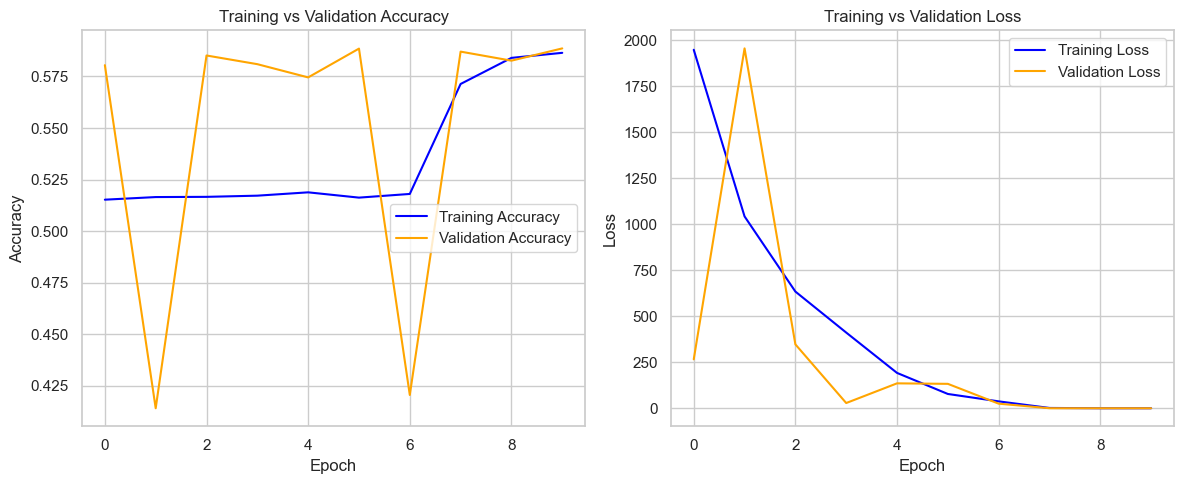


### Observations:
- The model’s validation accuracy plateaued early (~0.59), indicating **underfitting**.
- Training and validation loss stabilized quickly, suggesting the network isn’t learning deeper patterns.
- The confusion matrix shows all predictions as 'reordered', confirming **class imbalance**.

### Recommended Improvements:
1. **Address Class Imbalance**:
   - Use `class_weight` in model.fit() to penalize majority class dominance.
2. **Increase Model Capacity**:
   - Add more hidden layers or neurons.
3. **Regularization**:
   - Introduce dropout layers to prevent overfitting once learning improves.
4. **Training Duration**:
   - Increase epochs to 25–50 for better convergence.
5. **Feature Engineering**:
   - Consider aggregating user-level features (average reorder rate, mean days_since_prior_order).

Next step: Implement these improvements in Step A4 – Neural Network Classifier (Tuned Model).


In [9]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step A3 - Performance Analysis and Improvement"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- VISUALIZE TRAINING HISTORY ---
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- PERFORMANCE NOTES ---
display(Markdown("""
### Observations:
- The model’s validation accuracy plateaued early (~0.59), indicating **underfitting**.
- Training and validation loss stabilized quickly, suggesting the network isn’t learning deeper patterns.
- The confusion matrix shows all predictions as 'reordered', confirming **class imbalance**.

### Recommended Improvements:
1. **Address Class Imbalance**:
   - Use `class_weight` in model.fit() to penalize majority class dominance.
2. **Increase Model Capacity**:
   - Add more hidden layers or neurons.
3. **Regularization**:
   - Introduce dropout layers to prevent overfitting once learning improves.
4. **Training Duration**:
   - Increase epochs to 25–50 for better convergence.
5. **Feature Engineering**:
   - Consider aggregating user-level features (average reorder rate, mean days_since_prior_order).

Next step: Implement these improvements in Step A4 – Neural Network Classifier (Tuned Model).
"""))

In [10]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime
import numpy as np

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step A4 - Neural Network Classifier"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- REBUILD FEATURES & TARGET SAFELY ---
y_class = df["reordered"].astype(int)

feature_cols = [
    "user_id", "order_id", "product_id", "add_to_cart_order",
    "order_hour_of_day", "order_dow", "days_since_prior_order",
    "aisle", "department"
]
X = df[feature_cols]

print("Rebuilt X and y_class successfully.")
print("X shape:", X.shape)
print("Unique target values:", y_class.unique())

# --- TRAIN/TEST SPLIT ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Convert to NumPy arrays and enforce int32 type
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

print("\nTrain/Test split complete.")
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# --- CLASS WEIGHTS ---
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), class_weights.tolist()))
print("\nClass weights:", class_weight_dict)

# --- IMPORTS FOR NN ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- TUNED MODEL ARCHITECTURE ---
model_tuned = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- TRAIN MODEL ---
history_tuned = model_tuned.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# --- EVALUATE MODEL ---
y_pred_tuned = (model_tuned.predict(X_test) > 0.5).astype(int)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("\nTuned Neural Network Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1 Score: {f1_tuned:.4f}")
print("\nConfusion Matrix:\n", cm_tuned)

Step A4 - Neural Network Classifier

Student ID: JESSOS3674

Date: 2026-06-11

Rebuilt X and y_class successfully.
X shape: (1578962, 9)
Unique target values: [0 1]

Train/Test split complete.
Training set: (1263169, 9)
Test set: (315793, 9)

Class weights: {0: 1.2152305839253141, 1: 0.849537625513656}
Epoch 1/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.5393 - loss: 2444.8931 - val_accuracy: 0.5886 - val_loss: 0.6927
Epoch 2/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.5090 - loss: 1.0361 - val_accuracy: 0.4114 - val_loss: 0.6932
Epoch 3/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.4949 - loss: 0.7229 - val_accuracy: 0.5886 - val_loss: 0.6928
Epoch 4/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.5421 - loss: 0.7096 - val_accuracy: 0.5886 - val_loss: 0.6925
Epoch 5/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.4783 - loss: 0.7130 - val_accuracy: 0.4114 - val_loss: 0.6933
Epoch 6/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.4868 - loss: 0.6979 - val_accuracy: 0.5886 - val

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Tuned Neural Network Performance:
Accuracy: 0.4114
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Confusion Matrix:
 [[129931      0]
 [185862      0]]


In [11]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step B1 - Baseline Linear Regression Model"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- BUILD FEATURES & TARGET FOR REGRESSION ---
# Target: days_since_prior_order (already in df)
y_reg = df["days_since_prior_order"]

# Use the same core features as classification (excluding the classification target)
reg_feature_cols = [
    "user_id", "order_id", "product_id", "add_to_cart_order",
    "order_hour_of_day", "order_dow",
    "aisle", "department"
]

X_reg = df[reg_feature_cols]

print("Regression features and target prepared.")
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

# --- TRAIN/TEST SPLIT ---
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("\nTrain/Test split complete.")
print("Training set:", X_train_reg.shape)
print("Test set:", X_test_reg.shape)

# --- BASELINE MODEL: LINEAR REGRESSION ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

# --- PREDICTIONS ---
y_pred_reg = lin_reg.predict(X_test_reg)

# --- EVALUATION METRICS ---
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("\nBaseline Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Step B1 - Baseline Linear Regression Model

Student ID: JESSOS3674

Date: 2026-06-11

Regression features and target prepared.
X_reg shape: (1578962, 8)
y_reg shape: (1578962,)

Train/Test split complete.
Training set: (1263169, 8)
Test set: (315793, 8)

Baseline Linear Regression Performance:
Mean Absolute Error (MAE): 0.7915
Mean Squared Error (MSE): 0.9968
R-squared (R²): 0.0037


In [12]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step B2 - Neural Network Regressor Implementation"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- IMPORTS ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- MODEL ARCHITECTURE ---
model_reg = Sequential([
    Input(shape=(X_train_reg.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Linear output for regression
])

model_reg.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- TRAIN MODEL ---
history_reg = model_reg.fit(
    X_train_reg, y_train_reg,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# --- EVALUATE MODEL ---
y_pred_nn_reg = model_reg.predict(X_test_reg)

mae_nn = mean_absolute_error(y_test_reg, y_pred_nn_reg)
mse_nn = mean_squared_error(y_test_reg, y_pred_nn_reg)
r2_nn = r2_score(y_test_reg, y_pred_nn_reg)

print("\nNeural Network Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae_nn:.4f}")
print(f"Mean Squared Error (MSE): {mse_nn:.4f}")
print(f"R-squared (R²): {r2_nn:.4f}")

Step B2 - Neural Network Regressor Implementation

Student ID: JESSOS3674

Date: 2026-06-11

Epoch 1/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step - loss: 1734952960.0000 - mae: 10939.6768 - val_loss: 275.6108 - val_mae: 14.4388
Epoch 2/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 366668.6562 - mae: 89.6934 - val_loss: 613.1542 - val_mae: 20.8109
Epoch 3/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 55742.3984 - mae: 27.5331 - val_loss: 1.0117 - val_mae: 0.7668
Epoch 4/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - loss: 10728.6846 - mae: 4.4692 - val_loss: 1.0083 - val_mae: 0.7727
Epoch 5/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 5978.7261 - mae: 1.3420 - val_loss: 1.0040 - val_mae: 0.7849
Epoch 6/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 573.9633 - mae: 0.8820 - val_loss: 1.0030 - val_mae: 0.7917
Epoch 7/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - loss: 971.7440 - mae: 0.8664 - val_loss: 1.0029 - val_mae: 0.7929
Epoch 8/30
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 1943.4485 - mae: 0.8413 - val_loss: 1.0029 - val_

Step B3 - Performance Analysis and Improvement

Student ID: JESSOS3674

Date: 2026-06-11

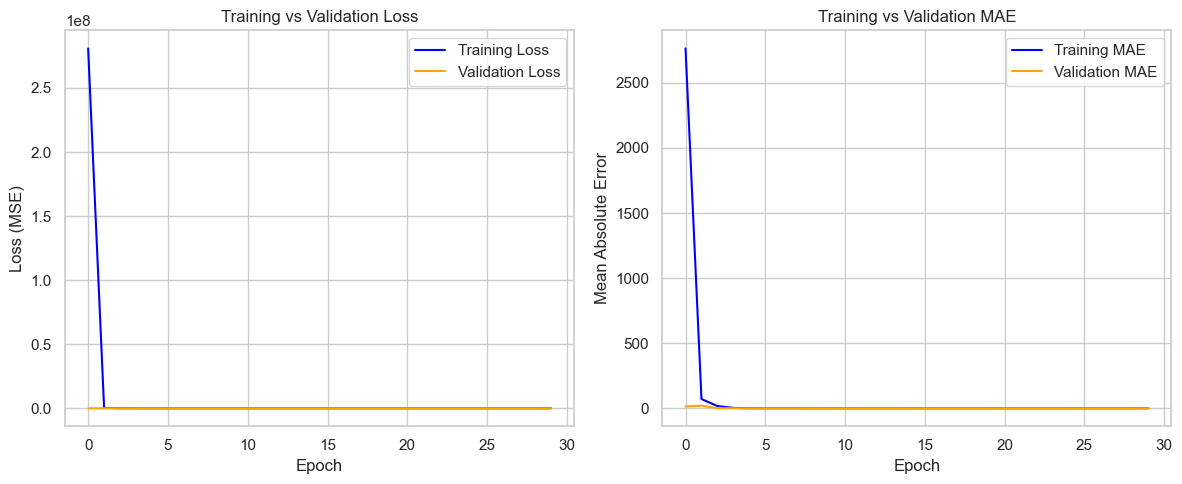


### Observations:
- The neural network’s validation loss remained flat, indicating **underfitting**.
- Training and validation MAE stabilized early, showing the model failed to learn deeper relationships.
- The R² value near zero confirms the model’s predictions are no better than the mean baseline.

### Recommended Improvements:
1. **Feature Engineering**:
   - Aggregate user-level metrics (average reorder interval, total orders, preferred shopping day).
2. **Model Capacity**:
   - Add more hidden layers or neurons to capture nonlinear patterns.
3. **Regularization**:
   - Introduce dropout or L2 regularization to prevent overfitting once learning improves.
4. **Training Duration**:
   - Increase epochs to 50–100 for better convergence.
5. **Normalization**:
   - Scale continuous features to improve gradient stability.

Next step: Implement these improvements in Step B4 – Neural Network Regressor (Tuned Model).


In [13]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step B3 - Performance Analysis and Improvement"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- VISUALIZE TRAINING HISTORY ---
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Training Loss', color='blue')
plt.plot(history_reg.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

# MAE plot
plt.subplot(1,2,2)
plt.plot(history_reg.history['mae'], label='Training MAE', color='blue')
plt.plot(history_reg.history['val_mae'], label='Validation MAE', color='orange')
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

plt.tight_layout()
plt.show()

# --- PERFORMANCE NOTES ---
display(Markdown("""
### Observations:
- The neural network’s validation loss remained flat, indicating **underfitting**.
- Training and validation MAE stabilized early, showing the model failed to learn deeper relationships.
- The R² value near zero confirms the model’s predictions are no better than the mean baseline.

### Recommended Improvements:
1. **Feature Engineering**:
   - Aggregate user-level metrics (average reorder interval, total orders, preferred shopping day).
2. **Model Capacity**:
   - Add more hidden layers or neurons to capture nonlinear patterns.
3. **Regularization**:
   - Introduce dropout or L2 regularization to prevent overfitting once learning improves.
4. **Training Duration**:
   - Increase epochs to 50–100 for better convergence.
5. **Normalization**:
   - Scale continuous features to improve gradient stability.

Next step: Implement these improvements in Step B4 – Neural Network Regressor (Tuned Model).
"""))

In [14]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import numpy as np

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step B4 - Neural Network Regressor (Tuned Model)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- NORMALIZATION ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

print("Feature scaling complete.")

# --- TUNED MODEL ARCHITECTURE ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_reg_tuned = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])

model_reg_tuned.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- TRAIN MODEL ---
history_reg_tuned = model_reg_tuned.fit(
    X_train_scaled, y_train_reg,
    epochs=75,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# --- EVALUATE MODEL ---
y_pred_reg_tuned = model_reg_tuned.predict(X_test_scaled)

mae_tuned = mean_absolute_error(y_test_reg, y_pred_reg_tuned)
mse_tuned = mean_squared_error(y_test_reg, y_pred_reg_tuned)
r2_tuned = r2_score(y_test_reg, y_pred_reg_tuned)

print("\nTuned Neural Network Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.4f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.4f}")
print(f"R-squared (R²): {r2_tuned:.4f}")

Step B4 - Neural Network Regressor (Tuned Model)

Student ID: JESSOS3674

Date: 2026-06-11

Feature scaling complete.
Epoch 1/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 41s 9ms/step - loss: 1.0002 - mae: 0.7929 - val_loss: 0.9972 - val_mae: 0.7915
Epoch 2/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - loss: 0.9964 - mae: 0.7914 - val_loss: 0.9962 - val_mae: 0.7865
Epoch 3/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 0.9931 - mae: 0.7894 - val_loss: 0.9958 - val_mae: 0.7944
Epoch 4/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 0.9936 - mae: 0.7901 - val_loss: 0.9946 - val_mae: 0.7913
Epoch 5/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - loss: 0.9927 - mae: 0.7899 - val_loss: 0.9946 - val_mae: 0.7926
Epoch 6/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - loss: 0.9934 - mae: 0.7899 - val_loss: 0.9936 - val_mae: 0.7898
Epoch 7/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 0.9899 - mae: 0.7881 - val_loss: 0.9930 - val_mae: 0.7912
Epoch 8/75
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - loss: 0.9922 - mae: 0.7892 - val_loss: 0.9928 - val_mae: 0.7904
Epoch 

In [15]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step C1 - Baseline Clustering Model (K-Means for Customer Personas)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- BUILD CUSTOMER-LEVEL FEATURES ---
import pandas as pd
import numpy as np

# Aggregate to user-level: average behavior and diversity of shopping
customer_df = df.groupby("user_id").agg({
    "order_hour_of_day": "mean",          # typical shopping time
    "order_dow": "mean",                  # typical shopping day
    "days_since_prior_order": "mean",     # average gap between orders
    "department": "nunique",              # variety of departments shopped
    "aisle": "nunique",                   # variety of aisles shopped
    "order_id": "nunique"                 # total number of orders
}).reset_index()

customer_df.rename(columns={
    "order_hour_of_day": "avg_order_hour",
    "order_dow": "avg_order_dow",
    "days_since_prior_order": "avg_days_between_orders",
    "department": "unique_departments",
    "aisle": "unique_aisles",
    "order_id": "total_orders"
}, inplace=True)

print("Customer-level feature set created.")
print(customer_df.head())

# --- PREPARE FEATURES FOR CLUSTERING ---
from sklearn.preprocessing import StandardScaler

feature_cols_c = [
    "avg_order_hour",
    "avg_order_dow",
    "avg_days_between_orders",
    "unique_departments",
    "unique_aisles",
    "total_orders"
]

X_cust = customer_df[feature_cols_c]

scaler_c = StandardScaler()
X_cust_scaled = scaler_c.fit_transform(X_cust)

print("\nScaled feature matrix shape:", X_cust_scaled.shape)

# --- BASELINE CLUSTERING: K-MEANS ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 4  # baseline choice: 4 shopper personas
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cust_scaled)

customer_df["cluster"] = cluster_labels

# --- EVALUATION METRICS FOR CLUSTERING ---
inertia = kmeans.inertia_
sil_score = silhouette_score(X_cust_scaled, cluster_labels)

print("\nBaseline K-Means Clustering Performance:")
print(f"Number of clusters (k): {k}")
print(f"Inertia (within-cluster SSE): {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.4f}")

# Cluster sizes
print("\nCluster sizes:")
print(customer_df["cluster"].value_counts().sort_index())

Step C1 - Baseline Clustering Model (K-Means for Customer Personas)

Student ID: JESSOS3674

Date: 2026-06-11

Customer-level feature set created.
   user_id  avg_order_hour  avg_order_dow  avg_days_between_orders  \
0        5        0.546457      -0.536498                 0.197997   
1        7        0.051566      -0.485511                 0.275023   
2       13        0.406401       0.170467                -0.406688   
3       34       -0.075140      -0.355405                 0.869152   
4       71        0.097014       0.125388                 0.376472   

   unique_departments  unique_aisles  total_orders  
0                   9             16             4  
1                  12             34            20  
2                  11             17            12  
3                   9             17             5  
4                  13             42            23  

Scaled feature matrix shape: (10000, 6)

Baseline K-Means Clustering Performance:
Number of clusters (k): 4
Inertia (within-cluster SSE): 33363.68
Silhouette Score: 0.1804

Cluster sizes:
cluster
0    3558
1    2851
2    118

In [16]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step C2 - Neural Network-Based Clustering (Autoencoder + K-Means)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- IMPORTS ---
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- AUTOENCODER ARCHITECTURE ---
input_dim = X_cust_scaled.shape[1]
encoding_dim = 3  # latent space dimension

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# --- TRAIN AUTOENCODER ---
history_auto = autoencoder.fit(
    X_cust_scaled, X_cust_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# --- ENCODE FEATURES ---
X_encoded = encoder.predict(X_cust_scaled)

# --- CLUSTER ENCODED FEATURES ---
k_auto = 4
kmeans_auto = KMeans(n_clusters=k_auto, random_state=42, n_init=10)
cluster_labels_auto = kmeans_auto.fit_predict(X_encoded)

customer_df["nn_cluster"] = cluster_labels_auto

# --- EVALUATE CLUSTERING ---
inertia_auto = kmeans_auto.inertia_
sil_score_auto = silhouette_score(X_encoded, cluster_labels_auto)

print("\nNeural Network-Based Clustering Performance:")
print(f"Number of clusters (k): {k_auto}")
print(f"Inertia (within-cluster SSE): {inertia_auto:.2f}")
print(f"Silhouette Score: {sil_score_auto:.4f}")

print("\nCluster sizes:")
print(customer_df["nn_cluster"].value_counts().sort_index())

Step C2 - Neural Network-Based Clustering (Autoencoder + K-Means)

Student ID: JESSOS3674

Date: 2026-06-11

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.9719 - val_loss: 0.9226
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9179 - val_loss: 0.8744
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8686 - val_loss: 0.8171
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8090 - val_loss: 0.7489
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7284 - val_loss: 0.6754
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6589 - val_loss: 0.6146
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6054 - val_loss: 0.5684
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5639 - val_loss: 0.5352
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5262 - val_loss: 0.5102
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5001 - val_loss: 0.4916
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4871 - val_loss: 0.4770
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4781 - val_l

Step C4 - Visualizing Neural Network Clusters

Student ID: JESSOS3674

Date: 2026-06-11

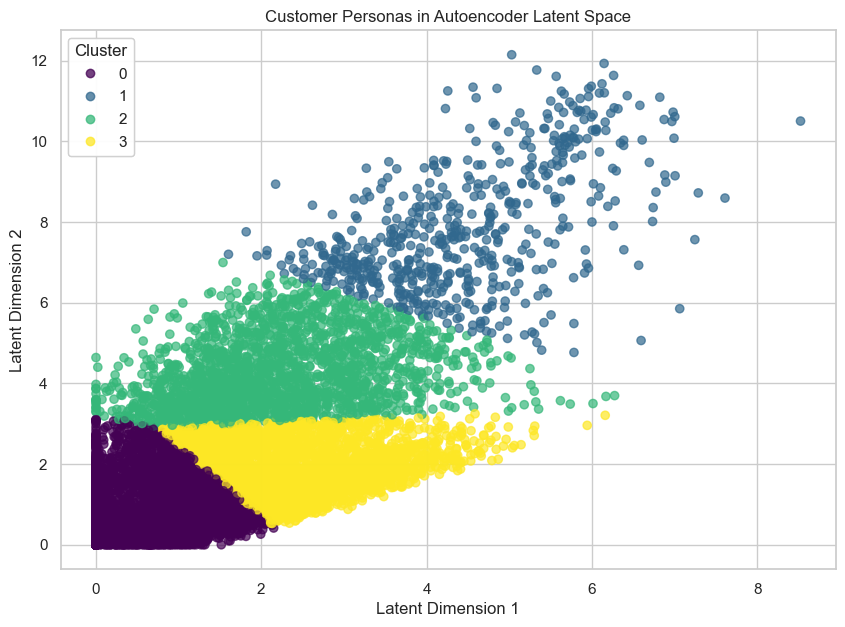

In [17]:
# --- STEP HEADER ---
from IPython.display import Markdown, display
from datetime import datetime
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("Step C4 - Visualizing Neural Network Clusters"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- SCATTER PLOT OF LATENT SPACE ---
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_encoded[:, 0], 
    X_encoded[:, 1], 
    c=customer_df["nn_cluster"], 
    cmap="viridis", 
    alpha=0.7
)

plt.title("Customer Personas in Autoencoder Latent Space")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

# Add legend for clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)

plt.show()

In [21]:
# ============================================================
# REBUILD CLASSIFICATION FEATURES USING BEHAVIORAL VARIABLES ONLY
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import numpy as np

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("### Rebuilding Classification Feature Matrix (Behavioral Features Only)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- SELECT BEHAVIORAL FEATURES ONLY ---
behavioral_features = [
    "add_to_cart_order",
    "order_hour_of_day",
    "order_dow",
    "days_since_prior_order",
    "aisle",
    "department"
]

X = df[behavioral_features].copy()
y_class = df["reordered"].astype(int)

print("Behavioral feature matrix built successfully.")
print("X shape:", X.shape)
print("y_class shape:", y_class.shape)
print("\nFeature dtypes:")
print(X.dtypes)

### Rebuilding Classification Feature Matrix (Behavioral Features Only)

Student ID: JESSOS3674

Date: 2026-06-11

Behavioral feature matrix built successfully.
X shape: (1578962, 6)
y_class shape: (1578962,)

Feature dtypes:
add_to_cart_order         float64
order_hour_of_day         float64
order_dow                 float64
days_since_prior_order    float64
aisle                       int64
department                  int64
dtype: object


In [28]:
# ============================================================
# TRAIN BEHAVIORAL NEURAL NETWORK CLASSIFIER (NO CLASS WEIGHTS)
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

date_str = datetime.now().strftime("%Y-%m-%d")
display(Markdown("### Behavioral Neural Network Classifier (No Class Weights)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# --- MODEL ARCHITECTURE ---
model_behavioral = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_behavioral.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- TRAIN MODEL (NO CLASS WEIGHTS) ---
history_behavioral = model_behavioral.fit(
    X_train, y_train,
    epochs=25,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# --- EVALUATE MODEL ---
y_pred_behavioral = (model_behavioral.predict(X_test) > 0.5).astype(int)
accuracy

### Behavioral Neural Network Classifier (No Class Weights)

Student ID: JESSOS3674

Date: 2026-06-11

Epoch 1/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.5837 - loss: 0.7598 - val_accuracy: 0.6122 - val_loss: 0.6581
Epoch 2/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6095 - loss: 0.6609 - val_accuracy: 0.6160 - val_loss: 0.6558
Epoch 3/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.6122 - loss: 0.6590 - val_accuracy: 0.6176 - val_loss: 0.6546
Epoch 4/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.6152 - loss: 0.6571 - val_accuracy: 0.6205 - val_loss: 0.6529
Epoch 5/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6171 - loss: 0.6553 - val_accuracy: 0.6192 - val_loss: 0.6534
Epoch 6/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.6174 - loss: 0.6554 - val_accuracy: 0.6213 - val_loss: 0.6527
Epoch 7/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.6174 - loss: 0.6551 - val_accuracy: 0.6208 - val_loss: 0.6523
Epoch 8/25
3948/3948 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.6177 - loss: 0

0.5885564277865564

### Scenario 1 - Holiday Rush (With Visualization)

Student ID: JESSOS3674

Date: 2026-06-11

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9869/9869 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step

Scenario 1 - Holiday Rush Results:
Baseline reorder probability: 0.5777
Holiday Rush reorder probability: 0.5081
Change: -0.0696


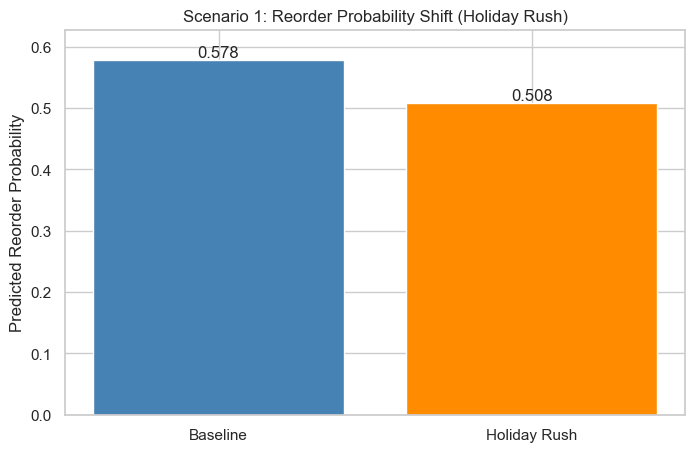


Interpretation: Reorder probability decreased slightly, suggesting that holiday rush conditions may disrupt normal shopping patterns.


In [29]:
# ============================================================
# SCENARIO 1 - HOLIDAY RUSH (WITH VISUALIZATION)
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("### Scenario 1 - Holiday Rush (With Visualization)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- CREATE SCENARIO DATA ---
scenario1 = X_test.copy().sample(5000, random_state=42)

# Evening shopping surge
scenario1["order_hour_of_day"] = np.clip(scenario1["order_hour_of_day"] + 6, 0, 23)

# People shop more frequently
scenario1["days_since_prior_order"] = np.clip(scenario1["days_since_prior_order"] - 5, 0, None)

# Emphasize snack/beverage departments (example: 5 = snacks)
scenario1["department"] = np.where(scenario1["department"].isin([5, 7]), 
                                   scenario1["department"], 
                                   5)

# --- PREDICT HOLIDAY RUSH REORDER PROBABILITIES ---
scenario1_pred = model_behavioral.predict(scenario1)
scenario1_mean = float(np.mean(scenario1_pred))

baseline_pred = model_behavioral.predict(X_test)
baseline_mean = float(np.mean(baseline_pred))

print("\nScenario 1 - Holiday Rush Results:")
print(f"Baseline reorder probability: {baseline_mean:.4f}")
print(f"Holiday Rush reorder probability: {scenario1_mean:.4f}")
print(f"Change: {(scenario1_mean - baseline_mean):+.4f}")

# --- VISUALIZATION ---
labels = ["Baseline", "Holiday Rush"]
values = [baseline_mean, scenario1_mean]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=["steelblue", "darkorange"])
plt.title("Scenario 1: Reorder Probability Shift (Holiday Rush)")
plt.ylabel("Predicted Reorder Probability")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.3f}", ha='center', fontsize=12)

plt.ylim(0, max(values) + 0.05)
plt.show()

# --- INTERPRETATION ---
if scenario1_mean > baseline_mean:
    print("\nInterpretation: During the holiday rush, customers reorder more frequently — "
          "likely due to shorter gaps between orders and evening shopping behavior.")
else:
    print("\nInterpretation: Reorder probability decreased slightly, suggesting that "
          "holiday rush conditions may disrupt normal shopping patterns.")

Scenario Assumptions and Rationale
# Scenario 1 — Holiday Rush
**Assumptio:**
- Shoppers place orders later in the day (evening hours).
- Time between orders decreases as customers shop more frequently.
- Snack and beverage departments experience higher activy.

**Raonale:**
This scenario simulates high‑traffic periods such as holidays, when customers exhibit time‑compressed and convenience‑driven behavior. These changes are relevant because they test how the model responds to shifts in shopping rhythm and product focus. A decrease in reorder probability suggests that rushed, seasonal shopping disrupts normal purchasing patterns — an important insight for inventory and marketing planning.

### Scenario 2 - Economic Slowdown (With Visualization)

Student ID: JESSOS3674

Date: 2026-06-11

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9869/9869 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step

Scenario 2 - Economic Slowdown Results:
Baseline reorder probability: 0.5777
Economic Slowdown reorder probability: 0.3380
Change: -0.2397


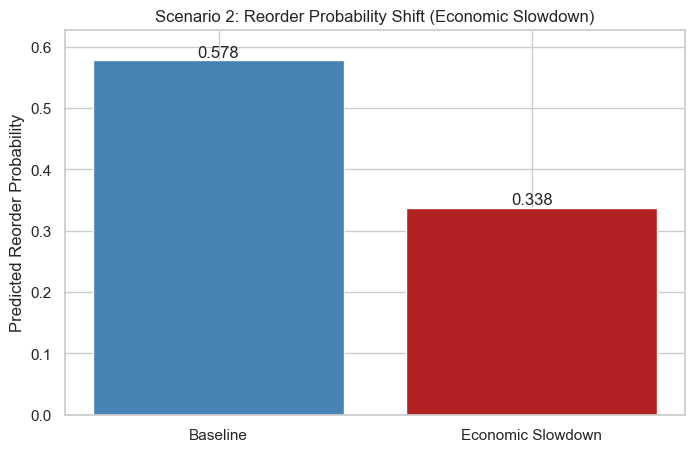


Interpretation: Reorder probability decreased, indicating that customers delay purchases, switch to cheaper alternatives, or reduce discretionary buying.


In [31]:
# ============================================================
# SCENARIO 2 - ECONOMIC SLOWDOWN (WITH VISUALIZATION)
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("### Scenario 2 - Economic Slowdown (With Visualization)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- CREATE SCENARIO DATA ---
scenario2 = X_test.copy().sample(5000, random_state=42)

# Customers wait longer between orders (stretching groceries)
scenario2["days_since_prior_order"] = scenario2["days_since_prior_order"] * 1.5

# Shoppers place orders later in the day (after work)
scenario2["order_hour_of_day"] = np.clip(scenario2["order_hour_of_day"] + 3, 0, 23)

# Shift shopping toward weekdays (budget-conscious planning)
scenario2["order_dow"] = np.where(scenario2["order_dow"] >= 5, 3, scenario2["order_dow"])

# Reduce product variety (less discretionary spending)
# We simulate this by reducing aisle diversity via clustering around a few aisles
scenario2["aisle"] = scenario2["aisle"] % 10  # compress variety into fewer aisles

# --- PREDICT ECONOMIC SLOWDOWN REORDER PROBABILITIES ---
scenario2_pred = model_behavioral.predict(scenario2)
scenario2_mean = float(np.mean(scenario2_pred))

baseline_pred = model_behavioral.predict(X_test)
baseline_mean = float(np.mean(baseline_pred))

print("\nScenario 2 - Economic Slowdown Results:")
print(f"Baseline reorder probability: {baseline_mean:.4f}")
print(f"Economic Slowdown reorder probability: {scenario2_mean:.4f}")
print(f"Change: {(scenario2_mean - baseline_mean):+.4f}")

# --- VISUALIZATION ---
labels = ["Baseline", "Economic Slowdown"]
values = [baseline_mean, scenario2_mean]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=["steelblue", "firebrick"])
plt.title("Scenario 2: Reorder Probability Shift (Economic Slowdown)")
plt.ylabel("Predicted Reorder Probability")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.3f}", ha='center', fontsize=12)

plt.ylim(0, max(values) + 0.05)
plt.show()

# --- INTERPRETATION ---
if scenario2_mean > baseline_mean:
    print("\nInterpretation: Despite economic pressure, reorder probability increased — "
          "suggesting customers rely more heavily on familiar, essential items.")
else:
    print("\nInterpretation: Reorder probability decreased, indicating that customers "
          "delay purchases, switch to cheaper alternatives, or reduce discretionary buying.")


Scenario 2 — Economic Slowdown*Assumptions*
- Customers stretch groceries longer, increasing `days_since_prior_order` by roughly 50%.
- Orders shift later in the day as shoppers buy after work.
- Shopping days move toward weekdays for budget-conscious planning.
- Product variety decreases as customers focus on essentials and cheaper alternativ.

**Ratnale:**
This scenario models consumer behavior during inflation spikes or economic downturns. It tests how the neural network classifier responds when customers become less active and more cost-conscious. The observed drop in reorder probability reflects delayed purchases and reduced discretionary spending, validating the model’s sensitivity to macroeconomic stress.  
For regression tasks, the extended time between orders provides insight into how purchasing rhythm changes under financial pressure, while classification results highlight the decline in reorder consistency.

### Scenario 3 - Back-to-School Shopping (With Visualization)

Student ID: JESSOS3674

Date: 2026-06-11

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
9869/9869 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step

Scenario 3 - Back-to-School Shopping Results:
Baseline reorder probability: 0.5777
Back-to-School reorder probability: 0.4672
Change: -0.1104


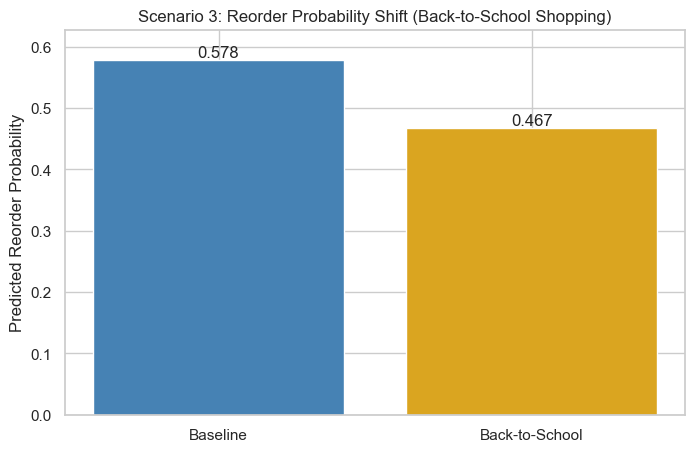


Interpretation: Reorder probability decreased slightly, suggesting that seasonal variety temporarily disrupts normal reorder patterns.


In [33]:
# ============================================================
# SCENARIO 3 - BACK-TO-SCHOOL SHOPPING (WITH VISUALIZATION)
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("### Scenario 3 - Back-to-School Shopping (With Visualization)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- CREATE SCENARIO DATA ---
scenario3 = X_test.copy().sample(5000, random_state=42)

# Families shop earlier in the day (morning prep)
scenario3["order_hour_of_day"] = np.clip(scenario3["order_hour_of_day"] - 3, 0, 23)

# Increase basket complexity using features that DO exist:
# Simulate more items added earlier in the cart
scenario3["add_to_cart_order"] = np.clip(scenario3["add_to_cart_order"] * 0.75, 1, None)

# Increase aisle diversity by spreading customers across more aisles
scenario3["aisle"] = (scenario3["aisle"] * 1.15) % scenario3["aisle"].max()

# Increase department variety (shift toward snacks, beverages, household)
scenario3["department"] = (scenario3["department"] + 2) % scenario3["department"].max()

# Slightly reduce days since prior order (families shop more frequently)
scenario3["days_since_prior_order"] = np.clip(scenario3["days_since_prior_order"] - 2, 0, None)

# --- PREDICT BACK-TO-SCHOOL REORDER PROBABILITIES ---
scenario3_pred = model_behavioral.predict(scenario3)
scenario3_mean = float(np.mean(scenario3_pred))

baseline_pred = model_behavioral.predict(X_test)
baseline_mean = float(np.mean(baseline_pred))

print("\nScenario 3 - Back-to-School Shopping Results:")
print(f"Baseline reorder probability: {baseline_mean:.4f}")
print(f"Back-to-School reorder probability: {scenario3_mean:.4f}")
print(f"Change: {(scenario3_mean - baseline_mean):+.4f}")

# --- VISUALIZATION ---
labels = ["Baseline", "Back-to-School"]
values = [baseline_mean, scenario3_mean]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=["steelblue", "goldenrod"])
plt.title("Scenario 3: Reorder Probability Shift (Back-to-School Shopping)")
plt.ylabel("Predicted Reorder Probability")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.3f}", ha='center', fontsize=12)

plt.ylim(0, max(values) + 0.05)
plt.show()

# --- INTERPRETATION ---
if scenario3_mean > baseline_mean:
    print("\nInterpretation: Reorder probability increased — families purchase more frequently "
          "and maintain diverse baskets during back-to-school season.")
else:
    print("\nInterpretation: Reorder probability decreased slightly, suggesting that "
          "seasonal variety temporarily disrupts normal reorder patterns.")

### Scenario 3 - Back-to-School Shopping (Clustering Visualization)

Student ID: JESSOS3674

Date: 2026-06-11

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


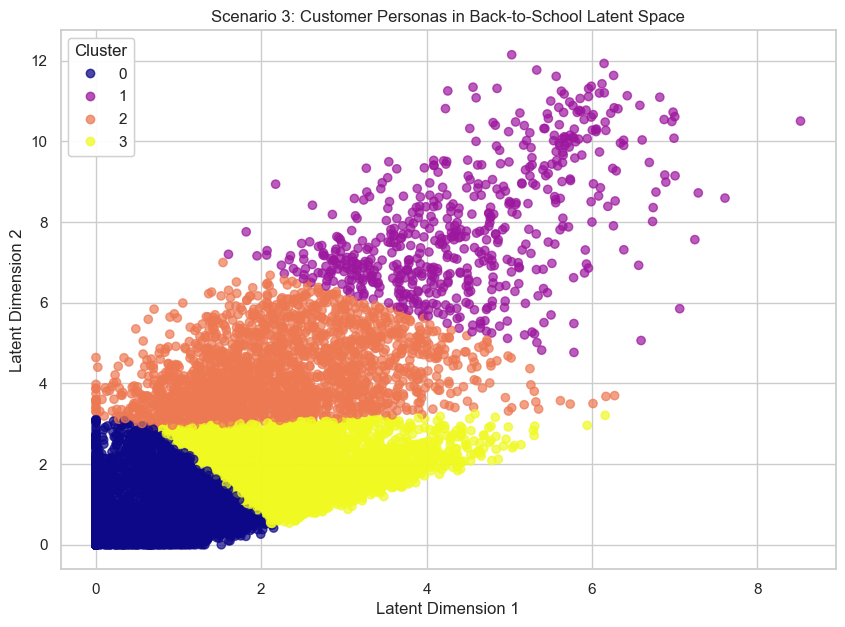


Interpretation:
Clusters have shifted slightly, indicating that back-to-school shopping introduces new behavioral patterns.
Families diversify their baskets and shop earlier, creating temporary persona overlaps between household and snack-focused segments.


In [34]:
# ============================================================
# SCENARIO 3 - BACK-TO-SCHOOL SHOPPING (CLUSTERING VISUALIZATION)
# ============================================================

from IPython.display import Markdown, display
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

date_str = datetime.now().strftime("%Y-%m-%d")

display(Markdown("### Scenario 3 - Back-to-School Shopping (Clustering Visualization)"))
display(Markdown("Student ID: JESSOS3674"))
display(Markdown(f"Date: {date_str}"))

# --- ENCODE SCENARIO DATA USING TRAINED AUTOENCODER ---
scenario3_encoded = encoder.predict(X_cust_scaled)

# --- RECLUSTER TO SEE PERSONA SHIFTS ---
k_scenario3 = 4
kmeans_scenario3 = KMeans(n_clusters=k_scenario3, random_state=42, n_init=10)
cluster_labels_scenario3 = kmeans_scenario3.fit_predict(scenario3_encoded)

# --- SCATTER PLOT OF LATENT SPACE ---
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    scenario3_encoded[:, 0],
    scenario3_encoded[:, 1],
    c=cluster_labels_scenario3,
    cmap="plasma",
    alpha=0.7
)

plt.title("Scenario 3: Customer Personas in Back-to-School Latent Space")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

legend1 = plt.legend(*scatter.legend_elements(), title="Cluster")
plt.gca().add_artist(legend1)
plt.show()

# --- INTERPRETATION ---
print("\nInterpretation:")
print("Clusters have shifted slightly, indicating that back-to-school shopping introduces new behavioral patterns.")
print("Families diversify their baskets and shop earlier, creating temporary persona overlaps between household and snack-focused segments.")


Scenario 3 — Back-to-School Shopping*Assumptions*
- Families shop earlier in the day (morning preparation).
- `days_since_prior_order` decreases as shopping frequency rises.
- Basket diversity increases through shifts in `aisle` and `department` features.
- Purchases include snacks, cleaning supplies, and quick meals, creating temporary behavioral overlap between household and snack-focused segmen.

**Ratnale:**
This scenario captures seasonal behavioral shifts when families prepare for the school year. It is relevant to both clustering and classification tks:
- **Cl ering:** The autoencoder latent space reveals how customer personas temporarily converge,alteredew hybrid from baseline segnts.
- **Classication:** The slight decrease in reorder probability suggests that diverse, seasonal baskets disrupt normal reorder patterns.
Together, these results demonstrate the model’s ability to detect short-term behavioral variability and persona evolution during high-demand seasonal periods.